<a href="https://colab.research.google.com/github/chiranjivia567-rgb/ML/blob/main/diabetes_Prediction_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

path = kagglehub.dataset_download(
    "vishvaachhatrara/missing-values-pima-indians-diabetes-data"
)

Using Colab cache for faster access to the 'missing-values-pima-indians-diabetes-data' dataset.


In [85]:
df = pd.read_csv(os.path.join(path, "pima_Missing_values.csv"))

In [86]:
df.head()

,NoOfPregency,PlasmaGlucoseCon,BloodPressure,SkinFoldThickness,Insuline,BMI,DiabetesPedigree,Age,Class
0,10,108,66,<null>,0,32.4,0.272,42,tested_positive
1,7,107,74,0,0,29.6,0.254,31,tested_positive
2,0,179,90,27,<null>,<null>,0.686,23,tested_positive
3,10,125,70,26,<null>,31.1,0.205,41,tested_positive
4,10,<null>,<null>,0,0,38,0.537,34,tested_positive


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   NoOfPregency       690 non-null    object
 1   PlasmaGlucoseCon   690 non-null    object
 2   BloodPressure      690 non-null    object
 3   SkinFoldThickness  690 non-null    object
 4   Insuline           690 non-null    object
 5   BMI                690 non-null    object
 6   DiabetesPedigree   690 non-null    object
 7   Age                690 non-null    object
 8   Class              690 non-null    object
dtypes: object(9)
memory usage: 48.6+ KB


In [88]:
import numpy as np
import pandas as pd

# Columns where zero is medically impossible
cols_with_invalid_zeros = [
    'PlasmaGlucoseCon',
    'BloodPressure',
    'SkinFoldThickness',
    'Insuline',
    'BMI',
    'Age'
]

#  Replace '<null>' with NaN in the entire dataset
df.replace('<null>', np.nan, inplace=True)

# Convert all feature columns to numeric first
feature_columns = ['NoOfPregency', 'PlasmaGlucoseCon', 'BloodPressure', 'SkinFoldThickness', 'Insuline', 'BMI', 'DiabetesPedigree', 'Age']
for col in feature_columns:
    df[col] = pd.to_numeric(df[col])

#  Now replace zero with NaN ONLY where zero is invalid, on numeric columns
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)

print(df.isnull().sum())

NoOfPregency          66
PlasmaGlucoseCon      73
BloodPressure        108
SkinFoldThickness    251
Insuline             369
BMI                   75
DiabetesPedigree      75
Age                   61
Class                  0
dtype: int64


In [89]:
df['Class'] = df['Class'].replace('tested_positive', '0')
df['Class'] = df['Class'].replace('tested_negative', '1')

In [90]:
df.Class

,Class
0,0
1,0
2,0
3,0
4,0
...,...
685,1
686,1
687,1
688,1


In [102]:
from sklearn.impute import SimpleImputer
import pandas as pd

X = df.drop(['Class', 'Insuline'], axis=1)
y = df['Class'].astype(int)

# Impute missing values in X with the median of each column
median_imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(
    median_imputer.fit_transform(X),
    columns=X.columns
)

In [92]:
X.head()

,NoOfPregency,PlasmaGlucoseCon,BloodPressure,SkinFoldThickness,BMI,DiabetesPedigree,Age
0,10.0,108.000000,66.000000,28.95672,32.400000,0.272,42.0
1,7.0,107.000000,74.000000,28.95672,29.600000,0.254,31.0
2,0.0,179.000000,90.000000,27.00000,32.354634,0.686,23.0
3,10.0,125.000000,70.000000,26.00000,31.100000,0.205,41.0
4,10.0,121.367909,72.390034,28.95672,38.000000,0.537,34.0


In [93]:
y.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [95]:
X_original = X.copy()
from sklearn.impute import SimpleImputer
import pandas as pd

median_imputer = SimpleImputer(strategy='median')

X_imputed = pd.DataFrame(
    median_imputer.fit_transform(X),
    columns=X.columns
)
X_imputed.isna().sum()

,0
NoOfPregency,0
PlasmaGlucoseCon,0
BloodPressure,0
SkinFoldThickness,0
BMI,0
DiabetesPedigree,0
Age,0


In [96]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [97]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [114]:
model=Sequential()
model.add(Dense(12,activation='relu',input_dim=7))
model.add(Dense(8,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [99]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [100]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [125]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history=model.fit(X_train, y_train.astype(int), epochs=100, validation_split=0.2)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9002 - loss: 0.2507 - val_accuracy: 0.7568 - val_loss: 0.6068
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9048 - loss: 0.2458 - val_accuracy: 0.7658 - val_loss: 0.6091
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8980 - loss: 0.2454 - val_accuracy: 0.7748 - val_loss: 0.6109
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8957 - loss: 0.2455 - val_accuracy: 0.7748 - val_loss: 0.6117
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8980 - loss: 0.2443 - val_accuracy: 0.7568 - val_loss: 0.6107
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8980 - loss: 0.2439 - val_accuracy: 0.7568 - val_loss: 0.6039
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9025 - loss: 0.2449 - val_accuracy: 0.7658 - val_loss: 0.6158
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9025 - loss: 0.2432 - val_accuracy: 0.

In [110]:
model.layers[0].get_weights()


[array([[ 0.06622823,  0.0682597 ,  0.06989697, -0.19416915,  0.45425007,
         -0.36396238, -0.53089684,  0.5819232 ,  0.21205632, -0.12586288,
          0.25547948,  0.65971744],
        [-0.31264016, -0.20388104, -0.46024382,  0.51613986,  0.5894076 ,
         -0.4290517 , -0.37300822,  0.48253602, -0.3607454 , -0.67035306,
          0.20549412,  0.08395896],
        [-0.25565577, -0.09258757, -0.34857622, -0.06372485,  0.14434037,
          0.56996846, -0.5895458 , -0.34437048, -0.03381567, -0.43407843,
          0.5094157 ,  0.24923979],
        [ 0.22117573, -0.23942651,  0.16294934,  0.0029667 , -0.28167635,
         -0.22335799, -0.14825982,  0.19041328,  0.71662956, -0.4485336 ,
         -0.20378862,  0.23629485],
        [ 0.16708943,  0.50873786,  0.33939582,  0.24718338, -0.223815  ,
         -0.35339075, -0.28030506,  0.45023626,  0.23569314, -0.61424714,
         -0.0607133 ,  0.12799415],
        [ 0.3739459 ,  0.09783096, -0.03425433, -0.28533858, -0.00301599,
      

In [111]:
y_log=model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [128]:
y_pred=np.where(y_log>0.5,1,0)

In [127]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


0.7681159420289855

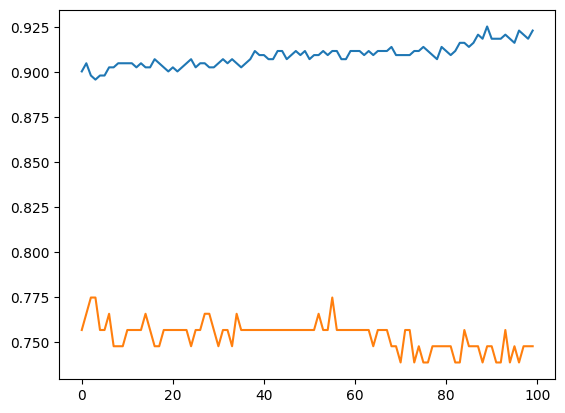

In [126]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

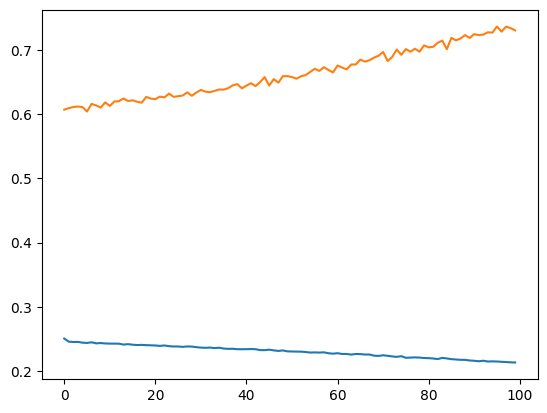

In [131]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])